In [1]:
import matplotlib.pyplot as plt

import sys
from os.path import dirname, abspath, join
import lightning as L
sys.path.append('G:/Codes/LuttingerWard_from_ML/code/models')
from model_FC import FC_01
from model_AE_FC import AE_FC_01
from model_AE_FC_transfer import AE_FC_02
sys.path.append('G:/Codes/LuttingerWard_from_ML/code/models/IO')
from DataMod_FC import *

import pytorch_lightning as L
import torch
from pytorch_lightning.loggers import TensorBoardLogger, NeptuneLogger, CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, StochasticWeightAveraging, GradientAccumulationScheduler,  DeviceStatsMonitor

from argparse import ArgumentParser
torch.set_float32_matmul_precision("high")
torch.set_default_dtype(torch.float64)
import json
import os, copy, gc

In [40]:
dir_name = 'G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01'
subfolders = [ f.path for f in os.scandir(dir_name) if f.is_dir() ]
checkpoints = []
checkpoints_paths = []
hparams_list = []
models_list = []
nparams_list = []
FC_nums = []
nparams2 = []
for dir in subfolders:
    ckp_path = os.path.join(os.path.join(dir_name,dir), 'checkpoints/last.ckpt') 
    checkpoint = torch.load(ckp_path, weights_only=False)
    checkpoints.append(checkpoint)
    checkpoints_paths.append(ckp_path)
    print(ckp_path)
    
    with open("../configs/confmod_FC.json") as f:
        json1_data = json.loads(f.read())
    hparams = checkpoint['hyper_parameters']
    for k in hparams:
        json1_data[k] = hparams[k]
    
    
    hparams_list.append(json1_data)
    model = FC_01.load_from_checkpoint(ckp_path, config=json1_data)
    fc_layers = model.hparams['latent_layers']
    model_nparams = sum(p.numel() for p in model.parameters())
    models_list.append(model)
    nparams_list.append(model_nparams)
    FC_nums.append(fc_layers)
nparams_list = np.array(nparams_list)
FC_nums = np.array(FC_nums) 

G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-192\checkpoints/last.ckpt


g:\miniconda3\envs\myenv\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-193\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-194\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-195\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-196\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-197\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-198\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-199\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-200\checkpoints/last.ckpt
G:/Codes/LuttingerWard_from_ML/.neptune/FC_scale_01\LWAEP-201\checkpoints/last.ckpt


In [3]:
model_loss_train_set = []
device="cpu"
test_set_paths = ["D:/data_batch2_nPrune.hdf5"]
tmp_hparams = copy.deepcopy(hparams_list[0])
tmp_hparams["PATH_TRAIN"] = test_set_paths[0]
tmp_hparams["num_workers"] = 0
tmp_hparams["persistent_workers"] = False
lossf = torch.nn.MSELoss()
with torch.no_grad():
    dataMod = DataMod_FC(tmp_hparams)
    dataMod.setup(stage='test')
    for model_i in range(len(models_list)):

        model = models_list[model_i]
        model.to(device)
        model.eval()
        chkp = checkpoints_paths[model_i]
        xdata,ydata  = dataMod.test_dataset[:]
        yhat = model(xdata)
        loss_i = lossf(yhat,ydata)
        model_nparams = sum(p.numel() for p in model.parameters())
        model_loss_train_set.append(loss_i)  
        print(f"{model_i} : {model.hparams['latent_layers']}. NB2 {loss_i}")
        del model
        del xdata
        del ydata 
        del yhat
        gc.collect()
    del dataMod
    gc.collect()
    model_loss_train_set = np.array(model_loss_train_set) 

0 : 1. NB2 0.0006627998394212131
1 : 2. NB2 1.9323691782641545e-05
2 : 3. NB2 2.137002972335274e-06
3 : 4. NB2 7.735500305633325e-07
4 : 5. NB2 8.678247830046797e-07
5 : 5. NB2 6.56503080843593e-07
6 : 6. NB2 4.710131155556171e-07
7 : 7. NB2 2.2179902898716093e-07
8 : 8. NB2 1.7519026666512464e-07
9 : 9. NB2 2.2784153940767995e-07


In [4]:

model_loss = []
model_loss_NB3 = []
model_loss_NB4 = []

device = "cpu"
test_set_paths = [["D:/NB2_f64_xdata.pt", "D:/NB2_f64_ydata.pt", 8320209],
                  ["D:/NB3_f64_xdata.pt", "D:/NB3_f64_ydata.pt", 9150901],
                  ["D:/NB4_f64_xdata.pt", "D:/NB4_f64_ydata.pt", 9510750]]
bs = 2**17

lossf = torch.nn.MSELoss()
for ii, test_path in enumerate(test_set_paths):
    tmp_hparams = copy.deepcopy(hparams_list[0])
    tmp_hparams["test_batch_size"] = bs
    tmp_hparams["batch_size"] = bs
    tmp_hparams["num_workers"] = 0
    tmp_hparams["persistent_workers"] = False
    with torch.no_grad():
        xdata = torch.from_file(test_path[0], size=test_path[2]*202).reshape(test_path[2],202)
        ydata = torch.from_file(test_path[1], size=test_path[2]*200).reshape(test_path[2],200)
        bn = test_path[2] // bs + 1
        for model_i in range(len(models_list)):

            model = models_list[model_i]
            model.to(device)
            model.eval()
            loss_i = 0.0
            for bi in range(bn):
                tti = lossf(model(xdata[bi*bs:(bi+1)*bs,:]),ydata[bi*bs:(bi+1)*bs,:])
                loss_i += tti*xdata[bi*bs:(bi+1)*bs,:].shape[0]
            loss_i = loss_i/test_path[2]
            print(f"{loss_i} over {bn}")

            if ii == 0:
                #loss_i = np.mean(.cpu() for x in model.test_step_outputs])
                model_loss.append(loss_i)
            if ii == 1:
                loss_i_NB3 = loss_i#np.mean([x.cpu() for x in model.test_step_outputs])
                model_loss_NB3.append(loss_i_NB3)
            if ii == 2:
                loss_i_NB4 = loss_i #np.mean([x.cpu() for x in model.test_step_outputs])
                model_loss_NB4.append(loss_i_NB4)

            #if ii == 0:
            #    model_nparams = sum(p.numel() for p in model.parameters())
            #    FC_nums.append(fc_layers)
            #    nparams2.append(model_nparams)    
            del model
            gc.collect()
        del xdata
        del ydata
        gc.collect()
model_loss = np.array(model_loss) 
loss_i_NB3 = np.array(loss_i_NB3) 
loss_i_NB4 = np.array(loss_i_NB4) 
nparams2 = np.array(nparams2)

0.0006564011074244421 over 64
2.9778312072447323e-05 over 64
6.514182672761868e-06 over 64
7.89095188834093e-06 over 64
3.7938883702420377e-06 over 64
3.6713687777598007e-06 over 64
5.868539824669787e-06 over 64
3.884533066569002e-06 over 64
5.493651535527164e-06 over 64
5.179567396184393e-06 over 64
0.000342031877069802 over 70
1.535644464195982e-05 over 70
2.6158274698104873e-06 over 70
1.811594837687605e-06 over 70
1.6801158997353322e-06 over 70
1.5163159082982165e-06 over 70
1.6924470130666605e-06 over 70
1.4618457255169593e-06 over 70
1.8236843099780278e-06 over 70
1.9432097424549442e-06 over 70
0.00021980244367132758 over 73
1.216022635535222e-05 over 73
1.03325582668529e-06 over 73
6.471821046870342e-07 over 73
9.489305404429216e-07 over 73
7.336791832146722e-07 over 73
6.087785472184885e-07 over 73
4.5332033972298036e-07 over 73
4.694855164913917e-07 over 73
5.494576775158042e-07 over 73


In [ ]:
               #dataMod = DataMod_FC(tmp_hparams)
        #dataMod.setup(stage='test') #trainer = L.Trainer(enable_checkpointing=False, inference_mode=True,  accelerator=device) 
        #chkp = checkpoints_paths[model_i]
        #trainer.test(model, datamodule=dataMod, ckpt_path=chkp)

In [18]:
model_loss_NB3 = np.array(model_loss_NB3)
model_loss_NB4 = np.array(model_loss_NB4)

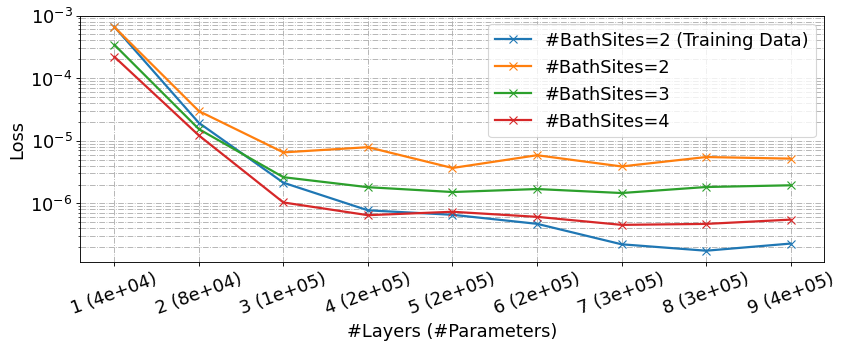

In [43]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(12, 4), dpi=80)

ind = [0,1,2,3,5,6,7,8,9]


ax = fig.add_subplot(111)
ax.set_yscale('log')

ax.plot(FC_nums[ind], model_loss_train_set[ind], marker='x', label="#BathSites=2 (Training Data)", linewidth=2, markersize=8)
ax.plot(FC_nums[ind], model_loss[ind], marker='x', label="#BathSites=2", linewidth=2, markersize=8)
ax.plot(FC_nums[ind], model_loss_NB3[ind], marker='x', label="#BathSites=3", linewidth=2, markersize=8)
ax.plot(FC_nums[ind], model_loss_NB4[ind], marker='x', label="#BathSites=4", linewidth=2, markersize=8)
ax.set_yscale('log')
ax.grid(axis="both", which="both", linestyle="-.")
ax.legend()
ax.set_xlabel("#Layers (#Parameters)")
ax.set_ylabel("Loss")
ax.set_xticks(FC_nums[ind], map(lambda x: f"{x[0]} ({x[1]:0.0e})", zip(FC_nums[ind],nparams_list[ind])),
       rotation=20) 

plt.savefig("FC_loss.pdf", bbox_inches='tight')

In [ ]:
model_i = 2
model = models_list[-1]
dataMod = DataMod_FC(hparams_list[model_i])
dataMod.setup(stage='test')
device = "cpu"
model.to(device)
model.eval()


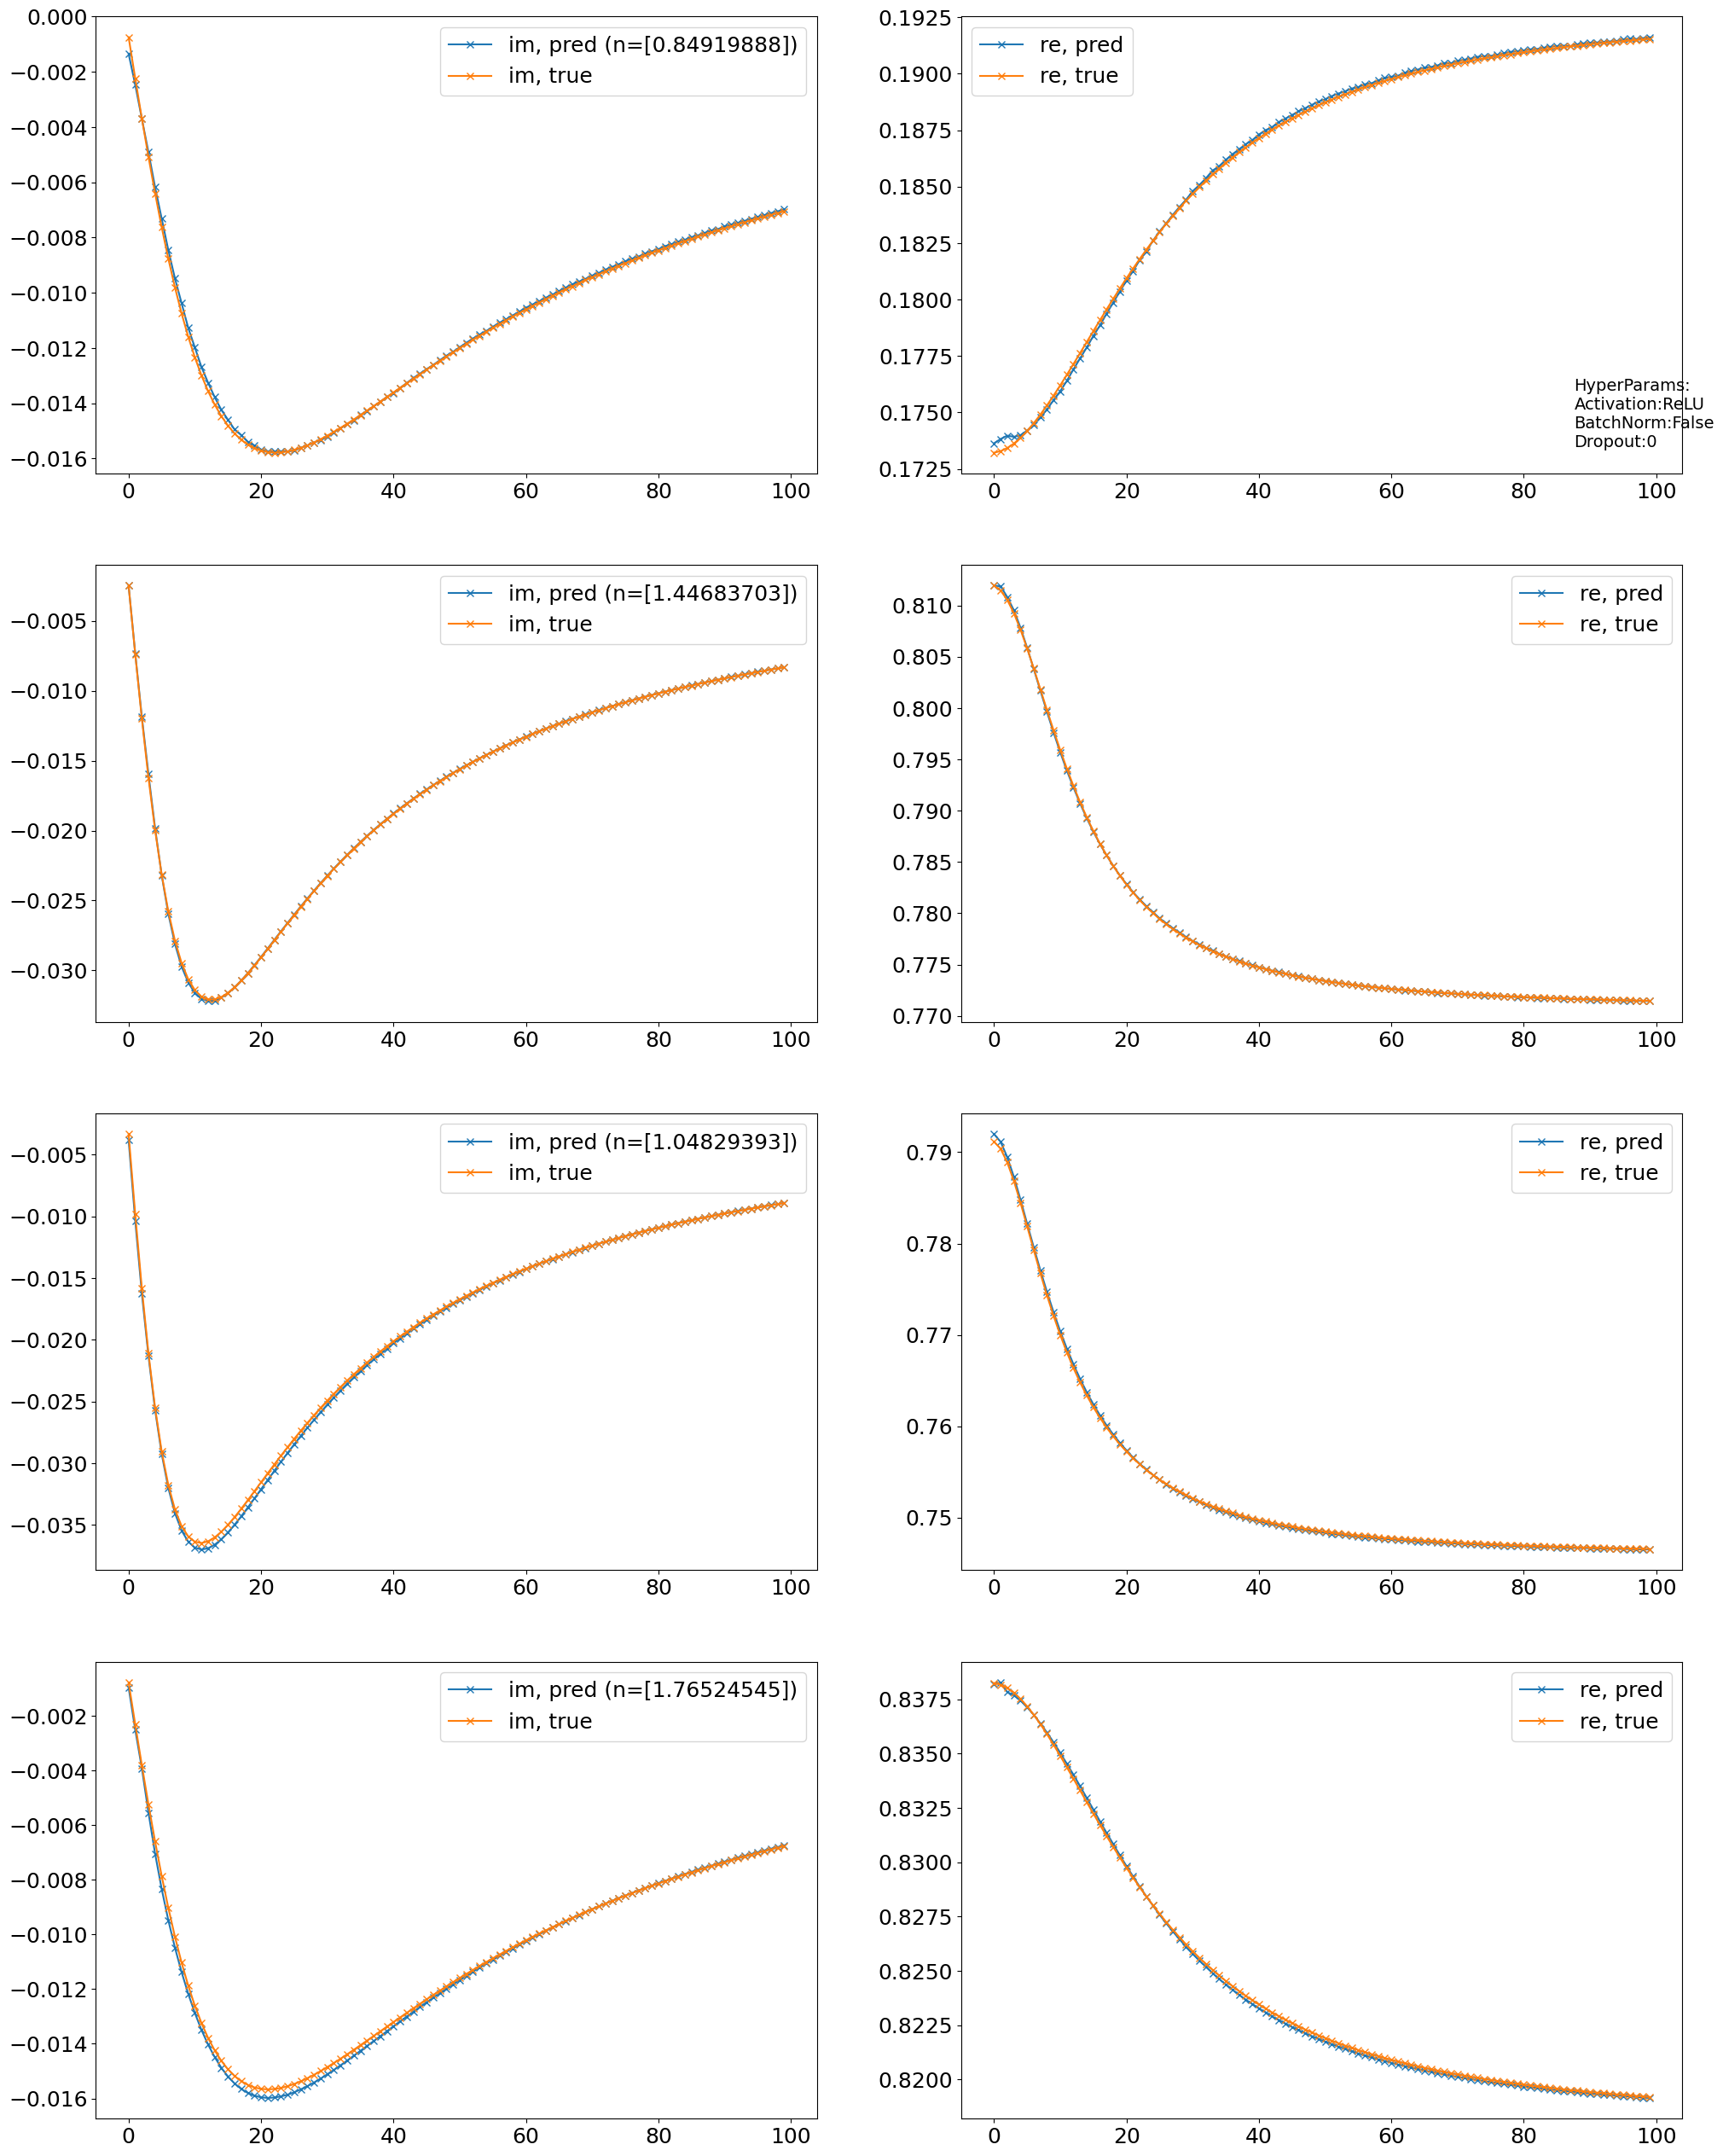

In [60]:
plt.rcParams.update({'font.size': 18})
ind_list = [5, -2,-1506,-1510]#,-1511,-1514,-1515, -1517, -1521]
fig,ax = plt.subplots(len(ind_list),2, figsize=(24,8*len(ind_list)))
tmp_hparams["PATH_TRAIN"] =  test_set_paths[2]#"D:/data_batch1_nPrune.hdf5"
dataMod = DataMod_FC(tmp_hparams)
dataMod.setup(stage='test')
x_test, SE_in = dataMod.val_dataset[ind_list]


x_test = x_test.to(device)
SE_hat = model(x_test)

for i,ind in enumerate(ind_list):
    if i == 0:
        text = "HyperParams:\nActivation:{}\nBatchNorm:{}\nDropout:{}".format(model.hparams["activation"],model.hparams["with_batchnorm"],model.hparams["dropout"])
        ax[i,1].text(0.85, 0.05, text, transform=ax[i,1].transAxes, fontsize=14,
        verticalalignment='bottom')
    y_pred = SE_hat.detach().numpy()[i]
    y_test = SE_in.detach().numpy()[i]
    ax[i,0].plot(y_pred[100:], marker="x", label="im, pred (n="+str(ndens.detach().numpy()[i])+")")
    ax[i,0].plot(y_test[100:], marker="x", label="im, true")
    ax[i,0].legend()

    ax[i,1].plot(y_pred[0:100], marker="x", label="re, pred")
    ax[i,1].plot(y_test[0:100], marker="x", label="re, true")
    ax[i,1].legend()
#fig.suptitle('No Dropout, Weighted, Medium Model Size, Medium Training Size ', fontsize=20)
plt.savefig("pred_FC_NB2_to_NB2.pdf")
plt.show()

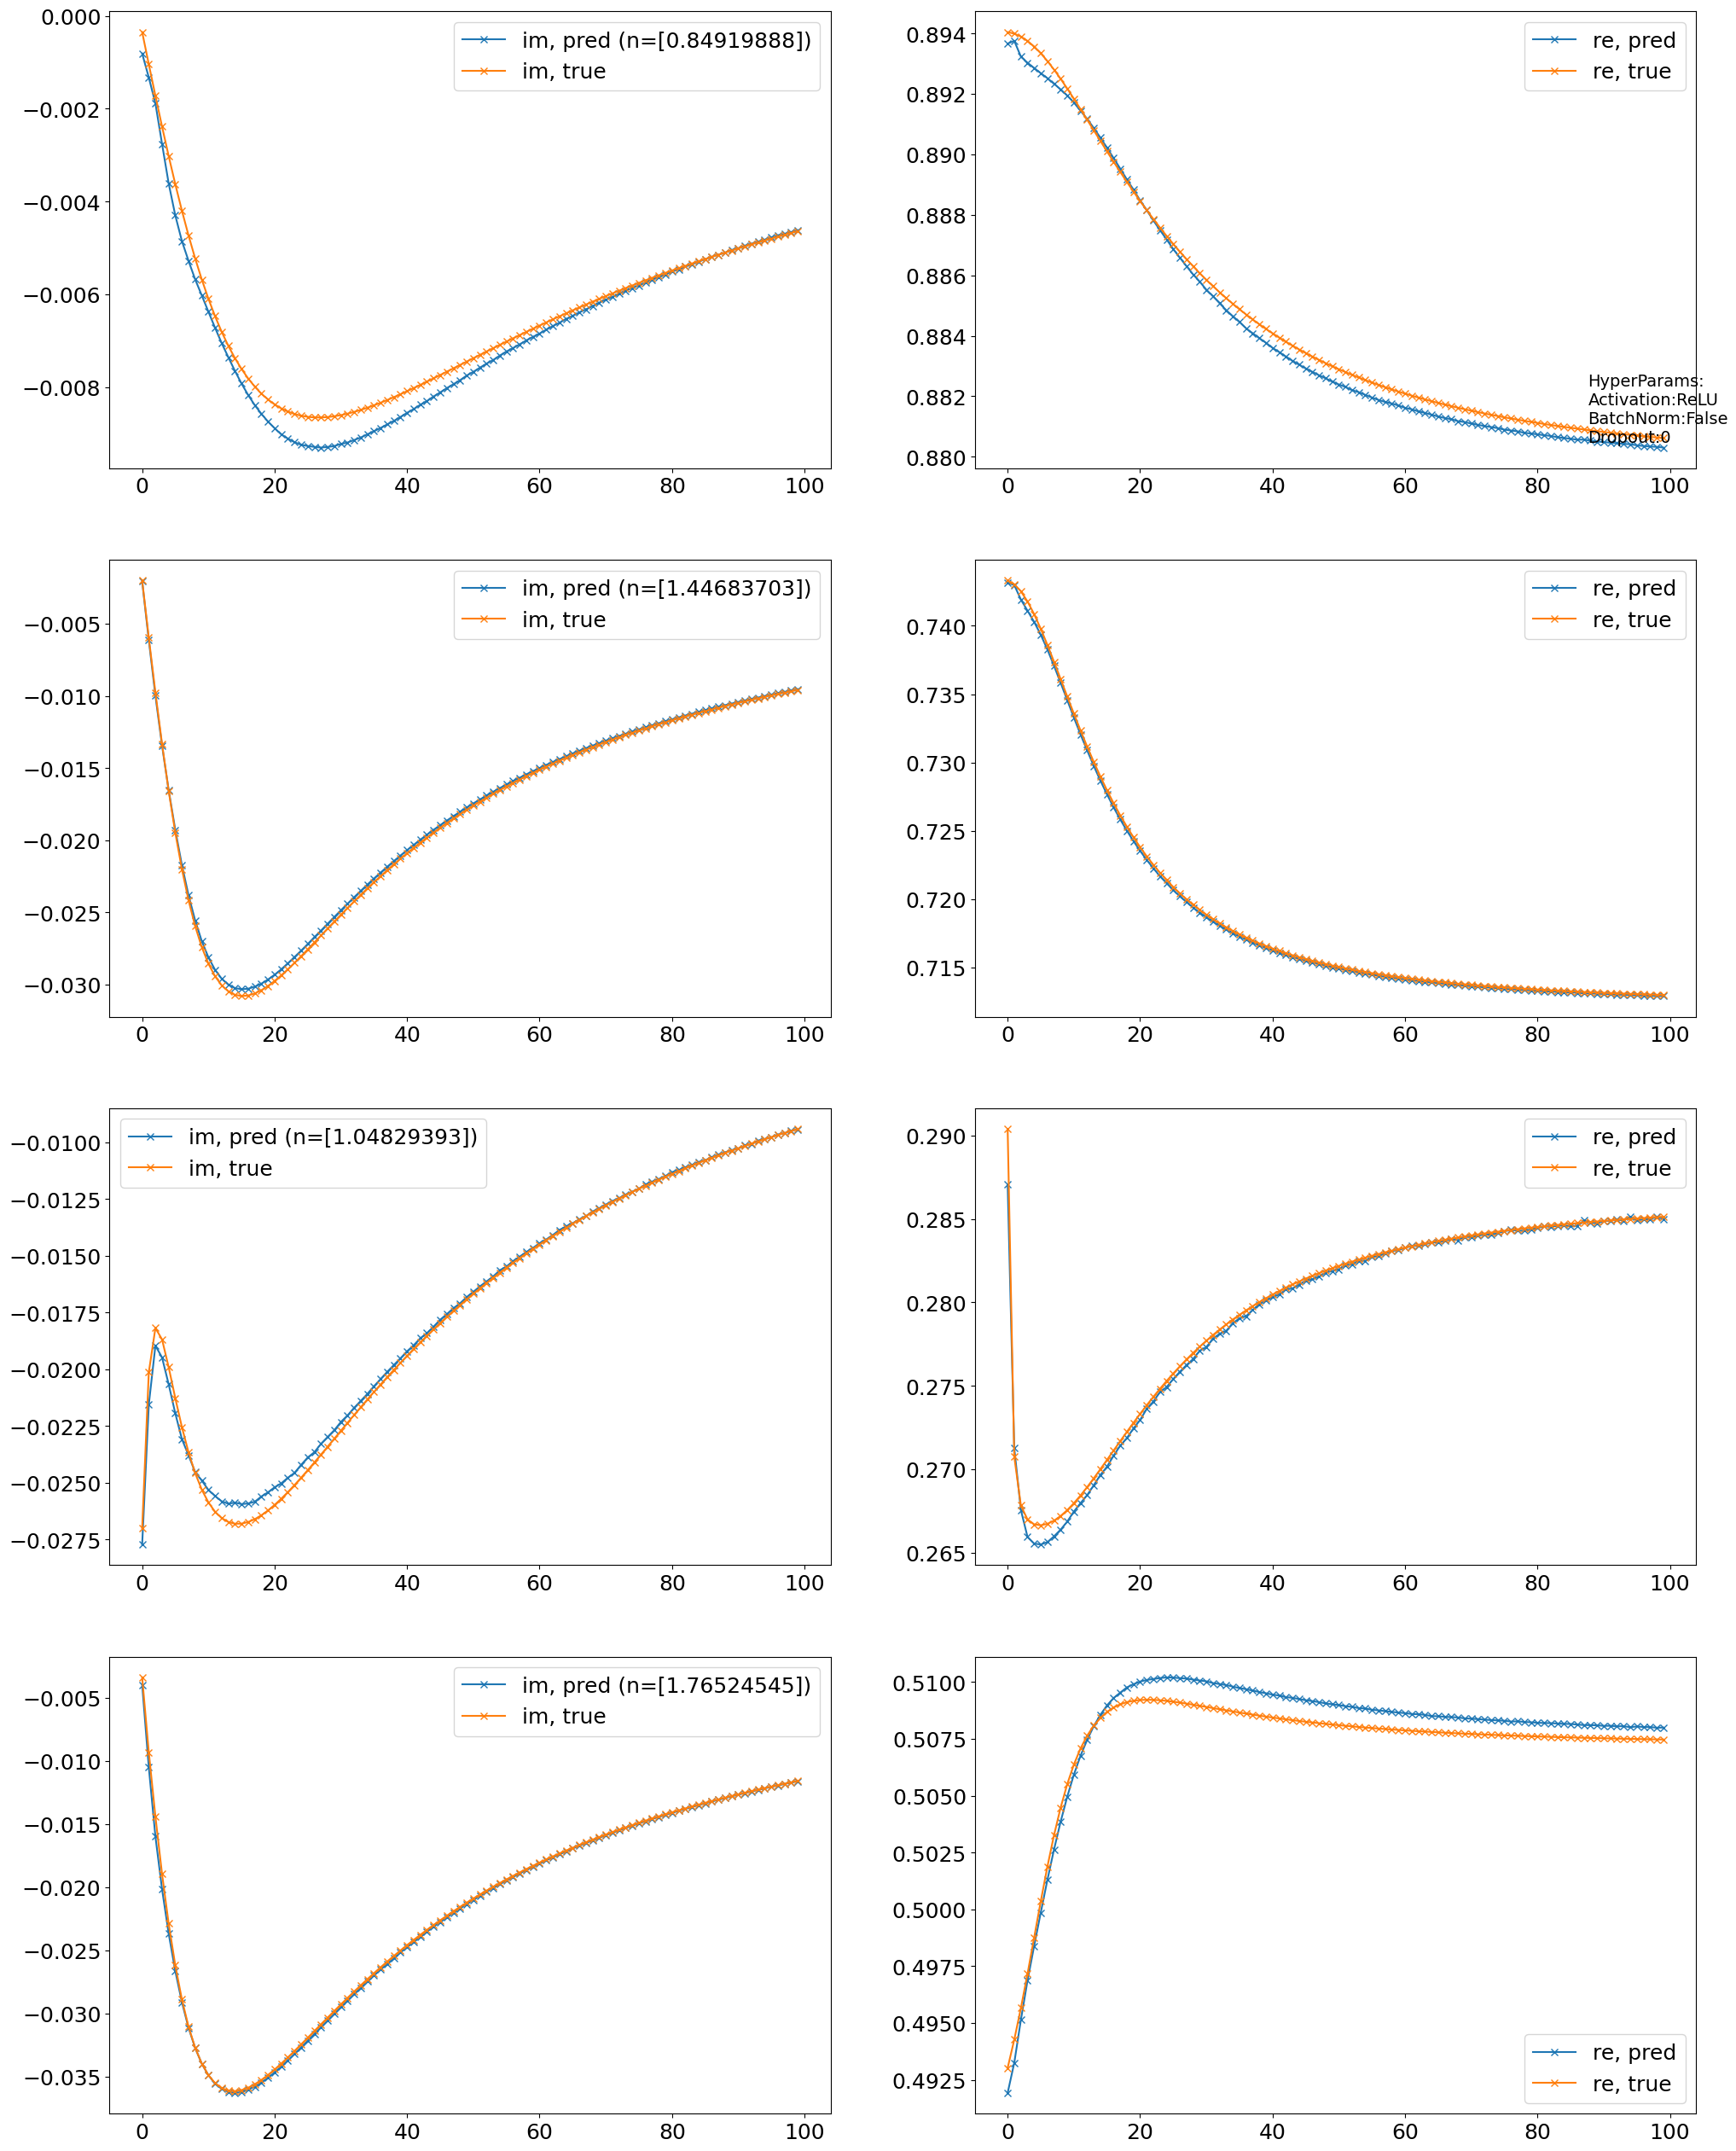

In [65]:
plt.rcParams.update({'font.size': 18})
ind_list = [-1, -2,-1505,-1510]#,-1511,-1514,-1515, -1517, -1521]1506
fig,ax = plt.subplots(len(ind_list),2, figsize=(24,8*len(ind_list)))

tmp_hparams = copy.deepcopy(hparams_list[-1])
tmp_hparams["PATH_TRAIN"] = "D:/data_batch1_NB4_nPrune.hdf5"
dataMod = DataMod_FC(tmp_hparams)
dataMod.setup(stage='test')
x_test, SE_in = dataMod.train_dataset[ind_list]

x_test = x_test.to(device)
SE_hat = model(x_test)

for i,ind in enumerate(ind_list):
    if i == 0:
        text = "HyperParams:\nActivation:{}\nBatchNorm:{}\nDropout:{}".format(model.hparams["activation"],model.hparams["with_batchnorm"],model.hparams["dropout"])
        ax[i,1].text(0.85, 0.05, text, transform=ax[i,1].transAxes, fontsize=14,
        verticalalignment='bottom')
    y_pred = SE_hat.detach().numpy()[i]
    y_test = SE_in.detach().numpy()[i]
    ax[i,0].plot(y_pred[100:], marker="x", label="im, pred (n="+str(ndens.detach().numpy()[i])+")")
    ax[i,0].plot(y_test[100:], marker="x", label="im, true")
    ax[i,0].legend()

    ax[i,1].plot(y_pred[0:100], marker="x", label="re, pred")
    ax[i,1].plot(y_test[0:100], marker="x", label="re, true")
    ax[i,1].legend()
#fig.suptitle('No Dropout, Weighted, Medium Model Size, Medium Training Size ', fontsize=20)
plt.savefig("pred_FC_NB2_to_NB4.pdf")
plt.show()

In [13]:
from juliacall import Main as jl
from juliacall import Pkg as jlPkg
import numpy as np
jlPkg.activate('G:/Codes/jED.jl')
jl.seval("using jED")

g:\miniconda3\envs\myenv\Lib\site-packages\juliacall\__init__.py:60: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: g:\miniconda3\envs\myenv\lib\site-packages\juliacall\juliapkg.json
[juliapkg] Found dependencies: g:\miniconda3\envs\myenv\lib\site-packages\juliapkg\juliapkg.json
[juliapkg] Locating Julia ~1.6.1, ~1.7, ~1.8, ~1.9, =1.10.0, ^1.10.3
[juliapkg] Installing Julia 1.11.2 using JuliaUp
[juliapkg] Using Julia 1.11.2 at C:\Users\Atomt\.julia\juliaup\julia-1.11.2+0.x64.w64.mingw32\bin\julia.exe
[juliapkg] Using Julia project at G:\miniconda3\envs\myenv\julia_env
[juliapkg] Installing packages:
           julia> import Pkg
           julia> Pkg.Registry.update()
           julia> Pkg.add([Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d")])
           julia> Pkg.resolve()
           julia> Pkg.precompile()


CalledProcessError: Command '['C:\\Users\\Atomt\\.julia\\juliaup\\julia-1.11.2+0.x64.w64.mingw32\\bin\\julia.exe', '--project=G:\\miniconda3\\envs\\myenv\\julia_env', '--startup-file=no', '-e', 'import Pkg; Pkg.Registry.update(); Pkg.add([Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d")]); Pkg.resolve(); Pkg.precompile()']' returned non-zero exit status 1.

In [223]:
beta = 30.0
U = 1.0
mu = 1.1
el    = [1.9, -1.0]
vl    = [0.25, 0.25]
AIMparams     = jl.jED.AIMParams(el, vl)
AIMparams_ML    = jl.jED.AIMParams(el, vl)
fieldEk,fieldVk = jl.fieldnames(jl.typeof(AIMparams))
tsc   = 0.40824829046386307/2
N_nu  = 100
Nk    = 80
α     = 1.0

GFImp_list  = []
GFImp_i_old = jl.nothing
SEImp_i     = []

kG     = jl.jED.gen_kGrid("3Dsc-"+str(tsc), Nk)
basis  = jl.jED.Basis(jl.length(vl) + 1);
overlap= jl.Overlap(basis, jl.create_op(basis, 1)) # optional
νnGrid = jl.seval("jED.OffsetVector([1im * (2*n+1)*π/30.0 for n in 0:"+str(N_nu)+"-1], 0:"+str(N_nu)+"-1)")

In [224]:
GFImp_list  = []
GFImp_ML_list = []
SEImp_list  = []
SEPred_it   = []
SEPred_tot  = []




for i in range(10):
    ImpModel  = jl.jED.AIM(jl.getfield(AIMparams,fieldEk), 
                              jl.getfield(AIMparams,fieldVk), mu, U)
    ImpModel_ML  = jl.jED.AIM(jl.getfield(AIMparams_ML,fieldEk), 
                              jl.getfield(AIMparams_ML,fieldVk), mu, U)
    G0W    = jl.jED.GWeiss(νnGrid, mu, AIMparams)
    es     = jl.jED.Eigenspace(ImpModel, basis)
    GImp_i, dens = jl.jED.calc_GF_1(basis, es, νnGrid, beta, overlap=overlap, with_density=True)
    GFImp_list.append(GImp_i)

    #G0W_ML    = jl.jED.GWeiss(νnGrid, mu, AIMparams_ML)
    #es_ML     = jl.jED.Eigenspace(ImpModel_ML, basis)
    #GImp_i_ML, dens_ML = jl.jED.calc_GF_1(basis, es_ML, νnGrid, beta, overlap=overlap, with_density=True)
    GImp_i_ML = GLoc_ML if i > 0 else GImp_i
    GFImp_ML_list.append(GImp_i_ML)

    x = np.reshape(GImp_i_ML, (1,100))
    x = np.concatenate((jl.real(x), jl.imag(x)), axis=1)
    x = np.c_[dens_ML, beta, np.array(x)]
    x = torch.tensor(x, dtype=torch.float64)
    y = model(x).detach().numpy()[0,:]
    SEPred_it.append(y)
    ΣImp_i = jl.jED.Σ_from_GImp(G0W, GFImp_list[-1])
    SEImp_list.append(ΣImp_i)
    GLoc_i = jl.jED.GLoc(SEImp_list[-1], mu, νnGrid, kG)
    tmp = SEImp_list[0]
    tmp[:] = y[0:100] + 1.0j*y[100:]
    GLoc_ML = jl.jED.GLoc(tmp, mu, νnGrid, kG)

    jl.jED.fit_AIM_params_b(AIMparams, GLoc_i, mu, νnGrid)
    print("Ek = ", jl.getfield(AIMparams,fieldEk) )
    print("Vk = ", jl.getfield(AIMparams,fieldVk), 
          "Sum-check= ", sum(pow(np.array(jl.getfield(AIMparams,fieldVk)),2.0)),
          "dens = ", dens)
    
    jl.jED.fit_AIM_params_b(AIMparams_ML, GLoc_ML, mu, νnGrid)
    print("Ek (ML) = ", jl.getfield(AIMparams_ML,fieldEk) )
    print("Vk (ML) = ", jl.getfield(AIMparams_ML,fieldVk), 
          "Sum-check= ", sum(pow(np.array(jl.getfield(AIMparams_ML,fieldVk)),2.0)))
    #print("Solution using Lsq:    ϵₖ = $(lpad.(round.(p.ϵₖ,digits=4),9)...)")
    #print("                       Vₖ = $(lpad.(round.(p.Vₖ,digits=4),9)...)")
    #print(" -> sum(Vₖ²) = $(sum(p.Vₖ .^ 2))")

Ek =  [0.14231525417791585, -0.20407139868601573]
Vk =  [0.25161281547835457, 0.2946561595137187] Sum-check=  0.15013126125231854 dens =  1.8090804786006984
Ek (ML) =  [0.14168454637340638, -0.2045507168488749]
Vk (ML) =  [0.2510937385400117, 0.2948244827034688] Sum-check=  0.14996954113536773
Eigenspace generated!                  
Ek =  [0.11484523503738847, -0.24965860074855223]
Vk =  [0.21900864342714307, 0.31680859858220134] Sum-check=  0.1483324740314159 dens =  1.4562597238583936
Ek (ML) =  [0.14354138108041584, -0.20728430895308617]
Vk (ML) =  [0.2518785260818459, 0.30074035594606746] Sum-check=  0.15388755359573048
Eigenspace generated!                  
Ek =  [0.11411469982252119, -0.251324325819071]
Vk =  [0.21774583389277066, 0.3163913902293838] Sum-check=  0.1475167599889403 dens =  1.4387471626928325
Ek (ML) =  [0.1434686150633865, -0.20737020184013355]
Vk (ML) =  [0.2518079067167197, 0.300792045755026] Sum-check=  0.15388307667454987
Eigenspace generated!                

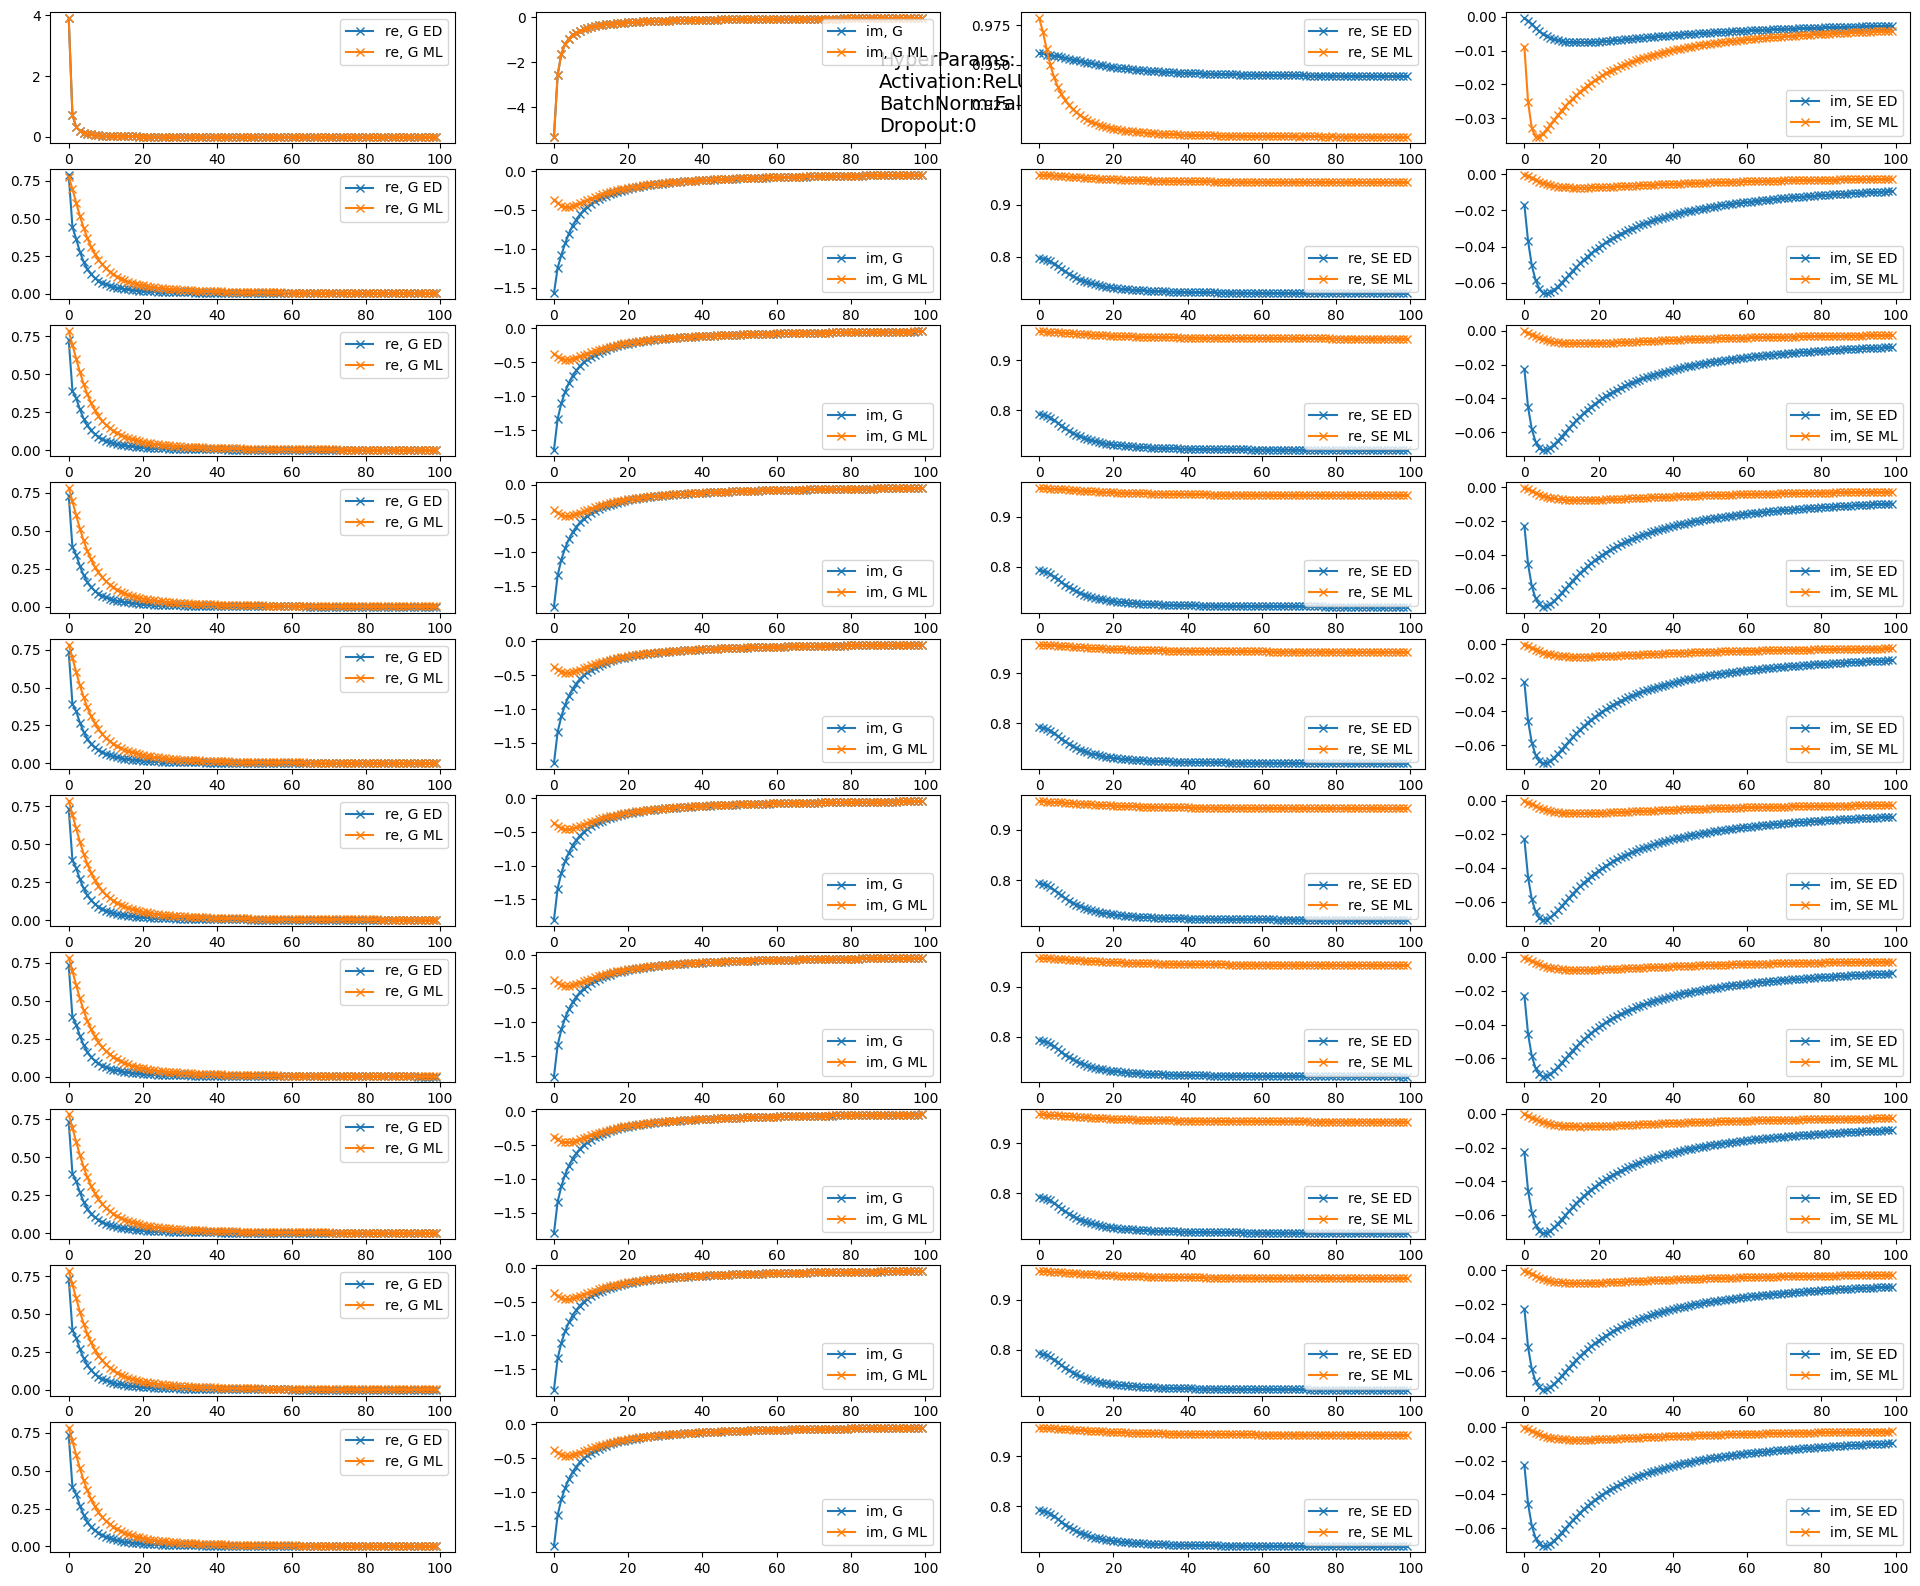

In [225]:
fig,ax = plt.subplots(len(GFImp_list),4, figsize=(24,2*len(GFImp_list)))

for i in range(len(GFImp_list)):


    if i == 0:
        text = "HyperParams:\nActivation:{}\nBatchNorm:{}\nDropout:{}".format(model.hparams["activation"],model.hparams["with_batchnorm"],model.hparams["dropout"])
        ax[i,1].text(0.85, 0.05, text, transform=ax[i,1].transAxes, fontsize=14,
        verticalalignment='bottom')
    ax[i,0].plot(jl.real(GFImp_list[i]), marker="x", label="re, G ED")
    ax[i,0].plot(jl.real(GFImp_ML_list[i]), marker="x", label="re, G ML")
    ax[i,0].legend()
    ax[i,1].plot(jl.imag(GFImp_list[i]), marker="x", label="im, G")
    ax[i,1].plot(jl.imag(GFImp_ML_list[i]), marker="x", label="im, G ML")
    ax[i,1].legend()

    ax[i,2].plot(jl.real(SEImp_list[i]), marker="x", label="re, SE ED")
    ax[i,2].plot(SEPred_it[i][0:100], marker="x", label="re, SE ML")
    ax[i,2].legend()
    ax[i,3].plot(jl.imag(SEImp_list[i]), marker="x", label="im, SE ED")
    ax[i,3].plot(SEPred_it[i][100:], marker="x", label="im, SE ML")
    ax[i,3].legend()

    #ax[i,4].plot(jl.real(SEImp_list[i]), marker="x", label="re, SE ED")
    #ax[i,4].plot(SEPred_it[i][0:100], marker="x", label="re, SE ML")
    #ax[i,4].legend()
    #ax[i,5].plot(jl.imag(SEImp_list[i]), marker="x", label="im, SE ED")
    #ax[i,5].plot(SEPred_it[i][100:], marker="x", label="im, SE ML")
    #ax[i,5].legend()

    
#fig.suptitle('No Dropout, Weighted, Medium Model Size, Medium Training Size ', fontsize=20)
plt.show()